In [1]:
from pathlib import Path

import wfdb
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data/samitrop_wfdb")

hea_files = sorted(DATA_DIR.glob("*.hea"))
record_paths = [str(p.with_suffix("")) for p in hea_files]

print(f"Number of WFDB records found: {len(record_paths)}")
print("First 5 records:")
for r in record_paths[:5]:
    print(r)

Matplotlib is building the font cache; this may take a moment.


Number of WFDB records found: 1631
First 5 records:
data/samitrop_wfdb/100726
data/samitrop_wfdb/101191
data/samitrop_wfdb/101193
data/samitrop_wfdb/101282
data/samitrop_wfdb/101842


In [2]:
record_path = record_paths[0]
record = wfdb.rdrecord(record_path)

def get_comment_value(record, key):
    key = key.lower()
    for comment in record.comments:
        if ":" in comment:
            name, value = comment.split(":", 1)
            if name.strip().lower() == key:
                return value.strip()
    return None

age = get_comment_value(record, "Age")
sex = get_comment_value(record, "Sex")

print("Record:", record_path)
print("Sampling frequency:", record.fs)
print("Number of leads:", record.n_sig)
print("Signal length:", record.sig_len)
print("Age:", age)
print("Sex:", sex)
print("Lead names:", record.sig_name)
print("Signal shape:", record.p_signal.shape)

Record: data/samitrop_wfdb/100726
Sampling frequency: 400
Number of leads: 12
Signal length: 2934
Age: 64
Sex: Male
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Signal shape: (2934, 12)


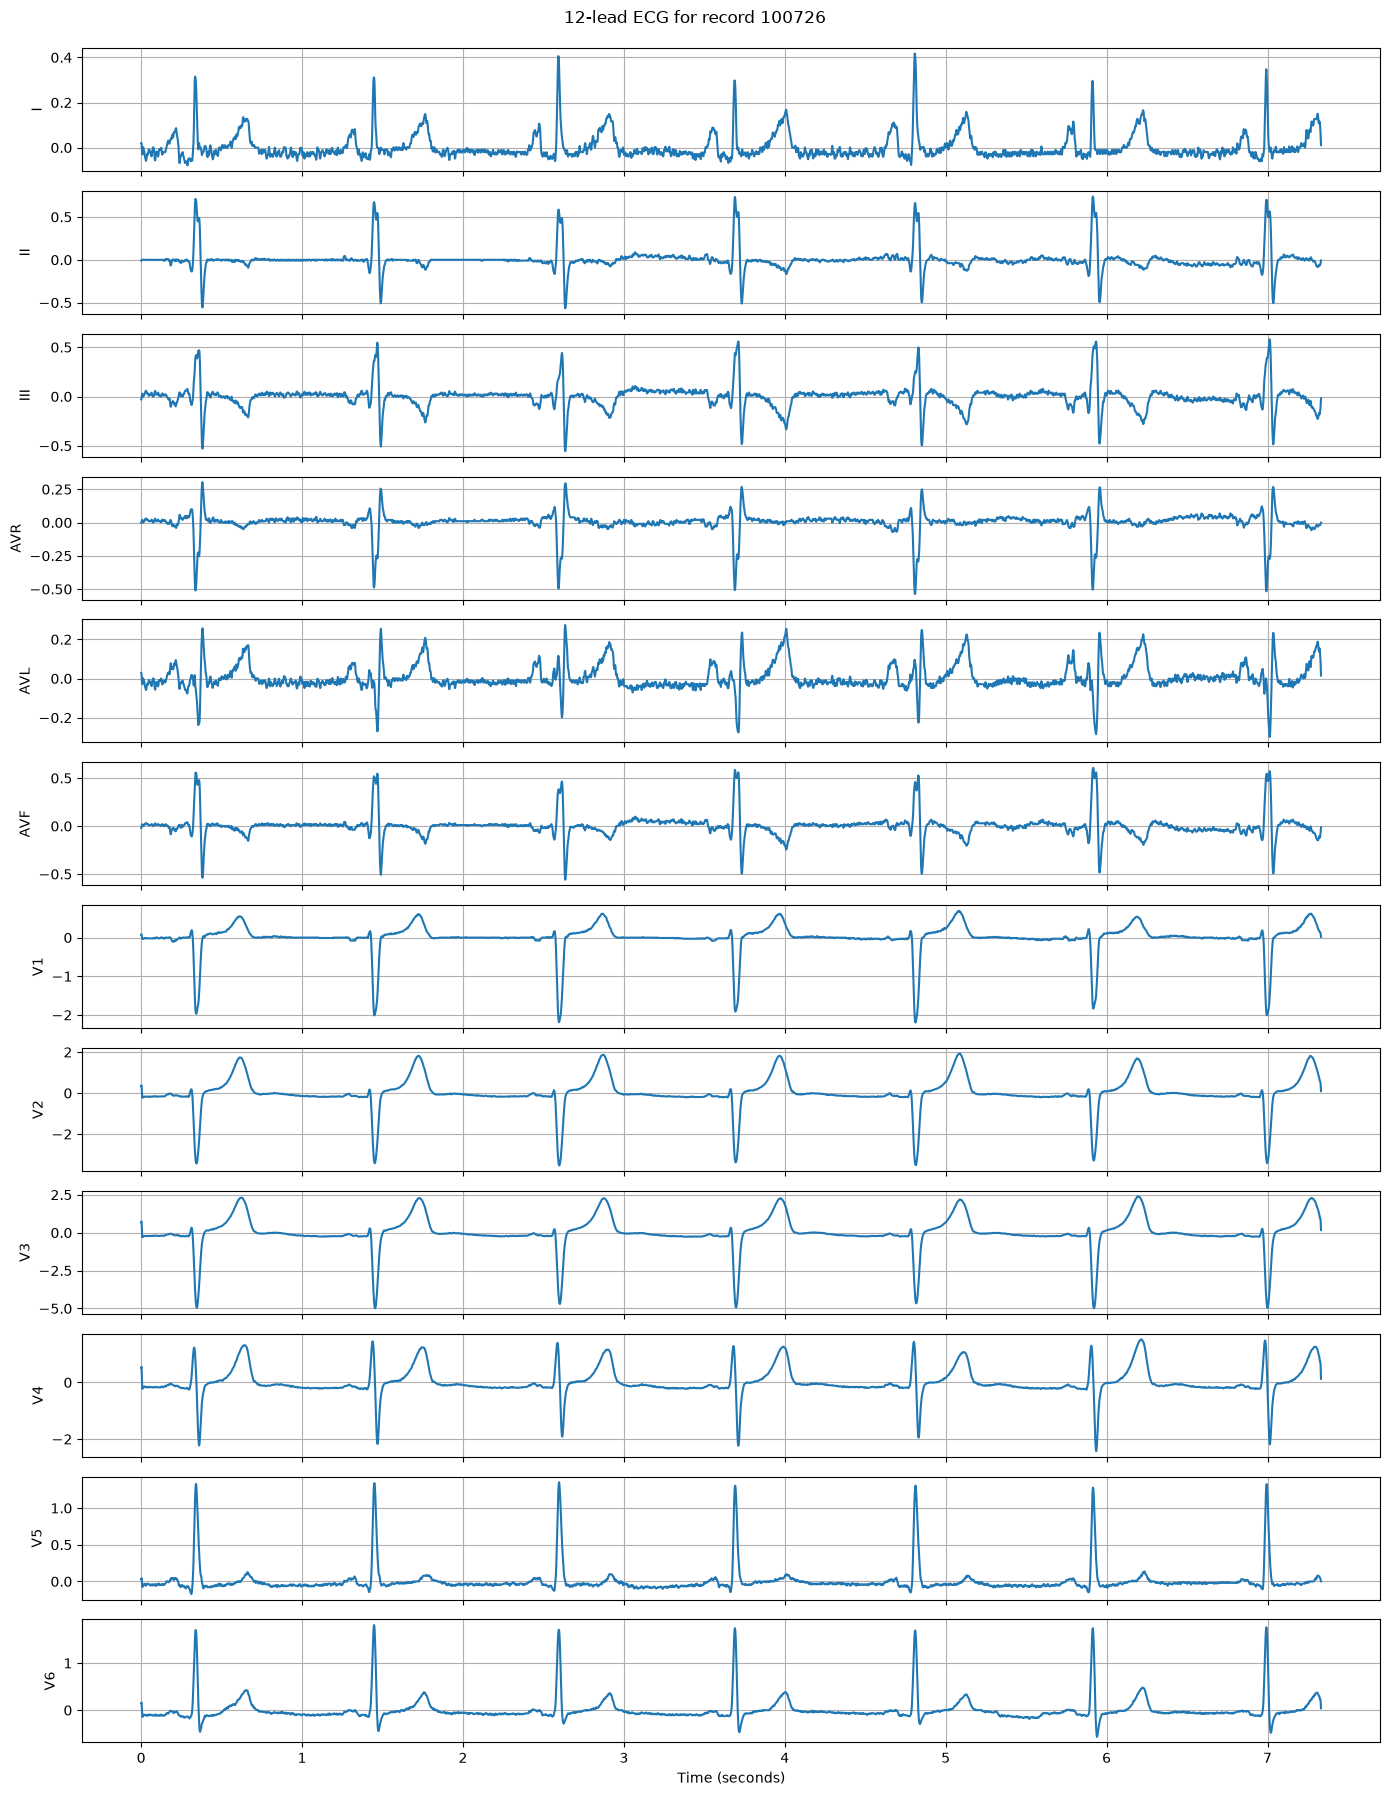

In [3]:
lead_names = ["I", "II", "III", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]

time = [i / record.fs for i in range(record.sig_len)]

fig, axes = plt.subplots(12, 1, figsize=(14, 18), sharex=True)

for i, lead in enumerate(lead_names):
    axes[i].plot(time, record.p_signal[:, i])
    axes[i].set_ylabel(lead)
    axes[i].grid(True)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle(f"12-lead ECG for record {Path(record_path).name}", y=0.995)
plt.tight_layout()
plt.show()

In [4]:
rows = []

for record_path in record_paths[:20]:
    record = wfdb.rdrecord(record_path)
    
    age = get_comment_value(record, "Age")
    sex = get_comment_value(record, "Sex")
    
    rows.append({
        "record_id": Path(record_path).name,
        "sampling_frequency": record.fs,
        "num_leads": record.n_sig,
        "signal_length": record.sig_len,
        "age": age,
        "sex": sex
    })

df_20 = pd.DataFrame(rows)
df_20

,record_id,sampling_frequency,num_leads,signal_length,age,sex
0,100726,400,12,2934,64,Male
1,101191,400,12,2934,49,Male
2,101193,400,12,2934,68,Female
3,101282,400,12,2934,70,Female
4,101842,400,12,2934,49,Female
5,102640,400,12,2934,72,Female
6,103042,400,12,2934,48,Female
7,103725,400,12,2934,74,Female
8,104023,400,12,2934,85,Female
9,105406,400,12,2934,76,Female
